In [1]:

import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

from pandas_datareader import data as web

series = {
    "CPI": "CPIAUCSL",
    "FED_RATE": "FEDFUNDS",
    "REAL_GDP": "GDPC1",
    "UNEMPLOYMENT": "UNRATE"
}

start_date = "2015-01-01"
end_date = "2026-09-24"

economic_frames = []

for indicator, fred_code in series.items():
    data = web.DataReader(
        fred_code,
        "fred",
        start_date,
        end_date
    )

    data = data.reset_index()
    data.columns = ["observation_date", "value"]
    data["indicator"] = indicator
    data["fred_series"] = fred_code

    economic_frames.append(data)

economic_data = pd.concat(
    economic_frames,
    ignore_index=True
)

economic_data["observation_date"] = (
    pd.to_datetime(economic_data["observation_date"])
    .dt.strftime("%Y-%m-%d")
)

economic_data = economic_data.dropna(
    subset=["value"]
)

print("Economic observations:", len(economic_data))
display(economic_data.head(10))

Economic observations: 464


,observation_date,value,indicator,fred_series
0,2015-01-01,234.747,CPI,CPIAUCSL
1,2015-02-01,235.342,CPI,CPIAUCSL
2,2015-03-01,235.976,CPI,CPIAUCSL
3,2015-04-01,236.222,CPI,CPIAUCSL
4,2015-05-01,237.001,CPI,CPIAUCSL
5,2015-06-01,237.657,CPI,CPIAUCSL
6,2015-07-01,238.034,CPI,CPIAUCSL
7,2015-08-01,238.033,CPI,CPIAUCSL
8,2015-09-01,237.498,CPI,CPIAUCSL
9,2015-10-01,237.733,CPI,CPIAUCSL


In [2]:

conn = sqlite3.connect("hedge_fund.db")

conn.execute("""
CREATE TABLE IF NOT EXISTS economic_data (
    observation_date TEXT NOT NULL,
    indicator TEXT NOT NULL,
    fred_series TEXT NOT NULL,
    value REAL NOT NULL,
    PRIMARY KEY (observation_date, indicator)
)
""")

economic_data.to_sql(
    "economic_data_staging",
    conn,
    if_exists="replace",
    index=False
)

conn.execute("""
INSERT OR REPLACE INTO economic_data
    (observation_date, indicator, fred_series, value)
SELECT
    observation_date,
    indicator,
    fred_series,
    value
FROM economic_data_staging
""")

conn.execute("DROP TABLE economic_data_staging")
conn.commit()

summary = pd.read_sql_query("""
SELECT
    indicator,
    COUNT(*) AS observations,
    MIN(observation_date) AS first_date,
    MAX(observation_date) AS latest_date
FROM economic_data
GROUP BY indicator
ORDER BY indicator
""", conn)

display(summary)

,indicator,observations,first_date,latest_date
0,CPI,139,2015-01-01,2026-08-01
1,FED_RATE,140,2015-01-01,2026-08-01
2,REAL_GDP,46,2015-01-01,2026-04-01
3,UNEMPLOYMENT,139,2015-01-01,2026-08-01


Economic Indicators and Growth Rates

In [3]:

# Load economic data from our SQL database

economic = pd.read_sql_query("""
    SELECT observation_date, indicator, value
    FROM economic_data
    ORDER BY observation_date
""", conn)

economic["observation_date"] = pd.to_datetime(
    economic["observation_date"]
)

economic_wide = economic.pivot(
    index="observation_date",
    columns="indicator",
    values="value"
).sort_index()

# CPI inflation: year-over-year change in the monthly CPI
cpi = economic_wide["CPI"].dropna()
inflation_yoy = cpi.pct_change(12) * 100

# Real GDP: quarter-over-quarter annualized growth
gdp = economic_wide["REAL_GDP"].dropna()
gdp_growth = ((gdp / gdp.shift(1)) ** 4 - 1) * 100

print("LATEST AVAILABLE INFLATION")
display(inflation_yoy.dropna().tail())

print("LATEST AVAILABLE GDP GROWTH")
display(gdp_growth.dropna().tail())

LATEST AVAILABLE INFLATION


observation_date
2026-04-01    3.947027
2026-05-01    4.270033
2026-06-01    3.726530
2026-07-01    3.539751
2026-08-01    3.712958
Name: CPI, dtype: float64

LATEST AVAILABLE GDP GROWTH


observation_date
2025-04-01    3.838033
2025-07-01    4.375396
2025-10-01    0.482248
2026-01-01    2.089189
2026-04-01    1.483659
Name: REAL_GDP, dtype: float64

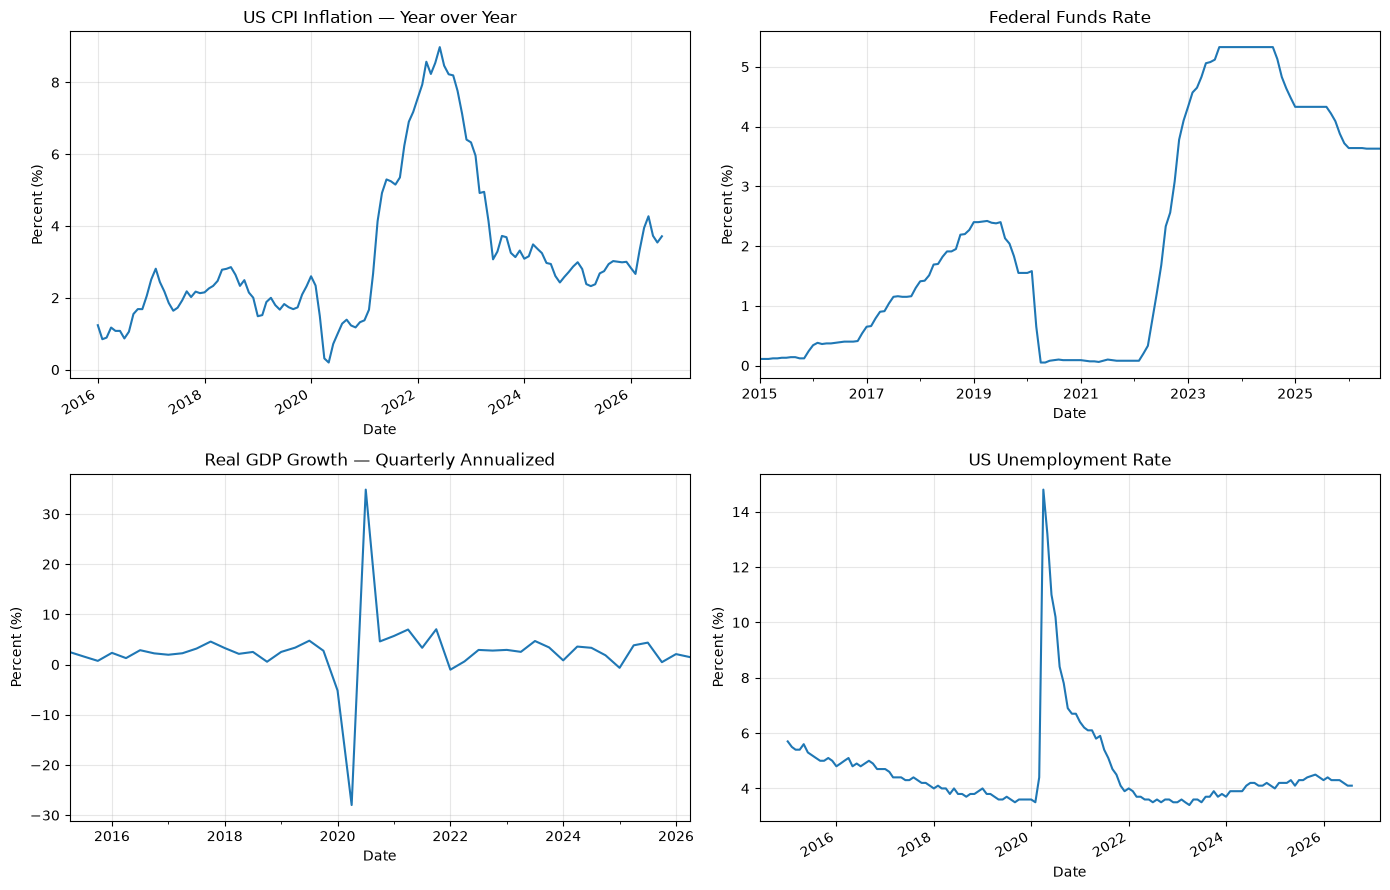

In [4]:

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

inflation_yoy.dropna().plot(
    ax=axes[0, 0],
    title="US CPI Inflation — Year over Year"
)
axes[0, 0].set_ylabel("Percent (%)")

economic_wide["FED_RATE"].dropna().plot(
    ax=axes[0, 1],
    title="Federal Funds Rate"
)
axes[0, 1].set_ylabel("Percent (%)")

gdp_growth.dropna().plot(
    ax=axes[1, 0],
    title="Real GDP Growth — Quarterly Annualized"
)
axes[1, 0].set_ylabel("Percent (%)")

economic_wide["UNEMPLOYMENT"].dropna().plot(
    ax=axes[1, 1],
    title="US Unemployment Rate"
)
axes[1, 1].set_ylabel("Percent (%)")

for ax in axes.flat:
    ax.grid(alpha=0.3)
    ax.set_xlabel("Date")

plt.tight_layout()
plt.show()

In [5]:

# Load existing stock prices

stocks = pd.read_sql_query("""
    SELECT date, ticker, close_price
    FROM daily_prices
    ORDER BY date, ticker
""", conn)

stocks["date"] = pd.to_datetime(stocks["date"])

stock_prices = stocks.pivot(
    index="date",
    columns="ticker",
    values="close_price"
).sort_index()

# Convert daily stock prices into month-end observations
monthly_prices = stock_prices.resample("ME").last()
monthly_returns = monthly_prices.pct_change().dropna()

# Put monthly economic indicators on month-end dates
monthly_macro = pd.DataFrame({
    "Inflation_YoY": inflation_yoy,
    "Fed_Rate": economic_wide["FED_RATE"],
    "Unemployment": economic_wide["UNEMPLOYMENT"]
})

monthly_macro.index = (
    monthly_macro.index.to_period("M").to_timestamp("M")
)

# Combine stock returns with same-month macro observations
research_dataset = monthly_returns.join(
    monthly_macro,
    how="left"
)

print("Monthly research dataset:")
display(research_dataset.tail(10))

Monthly research dataset:


,AAPL,BLK,GS,JPM,MSFT,Inflation_YoY,Fed_Rate,Unemployment
date,,,,,,,,
2025-12-31,-0.025067,0.026974,0.069388,0.029194,-0.017053,3.002262,3.72,4.4
2026-01-31,-0.045538,0.045406,0.064175,-0.046397,-0.110272,2.828680,3.64,4.3
2026-02-28,0.019066,-0.049788,-0.081077,-0.018275,-0.085184,2.664589,3.64,4.4
2026-03-31,-0.039329,-0.090447,-0.010619,-0.020446,-0.057468,3.320206,3.64,4.3
2026-04-30,0.069191,0.108026,0.091940,0.070278,0.101602,3.947027,3.64,4.3
2026-05-31,0.151087,-0.017568,0.110190,-0.044440,0.106516,4.270033,3.63,4.3
2026-06-30,-0.072742,-0.076323,-0.009490,0.093615,-0.171509,3.726530,3.63,4.2
2026-07-31,0.067563,0.133980,0.006931,0.079567,0.245831,3.539751,3.63,4.1
2026-08-31,0.026588,0.059813,0.007384,0.012024,0.093659,3.712958,3.63,4.1


In [6]:

# Day 24 — Save derived economic indicators

derived_indicators = pd.concat([
    inflation_yoy.rename("INFLATION_YOY"),
    gdp_growth.rename("GDP_GROWTH_ANNUALIZED")
], axis=1)

derived_long = (
    derived_indicators
    .reset_index()
    .melt(
        id_vars="observation_date",
        var_name="indicator",
        value_name="value"
    )
    .dropna(subset=["value"])
)

derived_long["observation_date"] = (
    pd.to_datetime(derived_long["observation_date"])
    .dt.strftime("%Y-%m-%d")
)

conn.execute("""
CREATE TABLE IF NOT EXISTS derived_economic_indicators (
    observation_date TEXT NOT NULL,
    indicator TEXT NOT NULL,
    value REAL NOT NULL,
    PRIMARY KEY (observation_date, indicator)
)
""")

conn.executemany("""
INSERT OR REPLACE INTO derived_economic_indicators
    (observation_date, indicator, value)
VALUES (?, ?, ?)
""", derived_long[
    ["observation_date", "indicator", "value"]
].itertuples(index=False, name=None))

conn.commit()

print("Derived observations saved:", len(derived_long))
display(derived_long.tail())

Derived observations saved: 172


C:\Users\nikit\AppData\Local\Temp\ipykernel_37676\1454388153.py:3: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  derived_indicators = pd.concat([


,observation_date,indicator,value
263,2025-04-01,GDP_GROWTH_ANNUALIZED,3.838033
266,2025-07-01,GDP_GROWTH_ANNUALIZED,4.375396
269,2025-10-01,GDP_GROWTH_ANNUALIZED,0.482248
272,2026-01-01,GDP_GROWTH_ANNUALIZED,2.089189
275,2026-04-01,GDP_GROWTH_ANNUALIZED,1.483659


In [7]:

# Verify raw and derived economic data

raw_summary = pd.read_sql_query("""
SELECT
    indicator,
    COUNT(*) AS observations,
    MAX(observation_date) AS latest_date
FROM economic_data
GROUP BY indicator
ORDER BY indicator
""", conn)

derived_summary = pd.read_sql_query("""
SELECT
    indicator,
    COUNT(*) AS observations,
    MAX(observation_date) AS latest_date
FROM derived_economic_indicators
GROUP BY indicator
ORDER BY indicator
""", conn)

print("RAW ECONOMIC DATA")
display(raw_summary)

print("DERIVED ECONOMIC INDICATORS")
display(derived_summary)

print("MONTHLY RESEARCH DATASET")
display(research_dataset.tail())

RAW ECONOMIC DATA


,indicator,observations,latest_date
0,CPI,139,2026-08-01
1,FED_RATE,140,2026-08-01
2,REAL_GDP,46,2026-04-01
3,UNEMPLOYMENT,139,2026-08-01


DERIVED ECONOMIC INDICATORS


,indicator,observations,latest_date
0,GDP_GROWTH_ANNUALIZED,45,2026-04-01
1,INFLATION_YOY,127,2026-08-01


MONTHLY RESEARCH DATASET


,AAPL,BLK,GS,JPM,MSFT,Inflation_YoY,Fed_Rate,Unemployment
date,,,,,,,,
2026-05-31,0.151087,-0.017568,0.110190,-0.044440,0.106516,4.270033,3.63,4.3
2026-06-30,-0.072742,-0.076323,-0.009490,0.093615,-0.171509,3.726530,3.63,4.2
2026-07-31,0.067563,0.133980,0.006931,0.079567,0.245831,3.539751,3.63,4.1
2026-08-31,0.026588,0.059813,0.007384,0.012024,0.093659,3.712958,3.63,4.1
2026-09-30,0.069844,-0.051700,-0.060251,-0.011179,-0.011197,NaN,NaN,NaN



## Day 24 — Findings and limitations

We integrated historical US economic data with our
existing five-stock research database.

### Economic indicators
- Consumer Price Index
- Federal funds rate
- Real GDP
- Unemployment rate
- Year-over-year CPI inflation
- Annualized quarterly real GDP growth

### Limitations
- Economic indicators have different observation frequencies.
- Publication dates differ from observation dates.
- Historical FRED values may have been revised.
- The monthly research dataset is descriptive only.
- Missing economic observations are not replaced
  with fabricated values.

### Next development
Introduce economic release dates and historical
data vintages before using economic indicators
in paper-trading backtests.